In [1]:
import pandas as pd

# Load the Excel file to inspect its content
file_path = '../Data/Mkt Data.xlsx'
# Reading the first sheet to understand structure
df = pd.read_excel(file_path, sheet_name=0)

# Display head and info
df.head(20)
df = df[['Unnamed: 0', 'MAT', 'MKT']].copy()
df.columns = ['Instrument', 'Maturity', 'MarketRate']
df_clean = df.copy()
display(df_clean)

,Instrument,Maturity,MarketRate
0,MM,0.25,0.030698
1,MM,0.50,0.026192
2,MM,0.75,0.023958
3,MM,1.00,0.022980
4,FUT,1.25,0.978692
5,FUT,1.50,0.977095
6,FUT,1.75,0.974982
7,FUT,2.00,0.972912
8,FUT,2.25,0.970984
9,FUT,2.50,0.969711


rmq : FUT 1.25 est le futur entre 1 et 1.25 an 


In [2]:
import numpy as np
import pandas as pd

# ==========================================
# 1. DÉFINITION DE LA FONCTION DE BOOTSTRAPPING
# ==========================================
def bootstrap_curve(df_market):
    """
    Calcule les facteurs d'actualisation et les taux zéro-coupon continus
    à partir d'un DataFrame contenant les instruments de marché.
    """
    df_sorted = df_market.sort_values(by='Maturity').copy()

    results = []
    curve = {0.0: 1.0} # Le facteur d'actualisation à t=0 est toujours 1

    for index, row in df_sorted.iterrows():
        instr = row['Instrument']
        mat = row['Maturity']
        rate = row['MarketRate']

        df_val = np.nan
        zc_rate = np.nan

        # 1. Money Market (Dépôts)
        if instr == 'MM':
            df_val = 1.0 / (1.0 + rate * mat)

        # 2. Futures (Contrats à terme)
        elif instr == 'FUT':
            implied_rate = 1.0 - rate
            delta = 0.25
            prev_mat = mat - delta

            prev_mat_key = round(prev_mat, 2)
            if prev_mat_key in curve:
                 df_prev = curve[prev_mat_key]
            else:
                 keys = np.array(list(curve.keys()))
                 closest_key = keys[np.abs(keys - prev_mat_key).argmin()]
                 df_prev = curve[closest_key]

            df_val = df_prev / (1.0 + implied_rate * delta)

        # 3. Swaps
        elif instr == 'SWAP':
            coupon_dates = np.arange(1, int(mat))
            sum_df = 0.0
            for t in coupon_dates:
                t_key = round(float(t), 2)
                if t_key in curve:
                    sum_df += curve[t_key]

            df_val = (1.0 - rate * sum_df) / (1.0 + rate)

        # Sauvegarde dans le dictionnaire pour les itérations suivantes
        curve[round(mat, 2)] = df_val

        # Calcul du Taux Zéro-Coupon Continu
        if mat > 0:
            zc_rate = -np.log(df_val) / mat

        # Stockage des résultats
        results.append({
            'Instrument': instr,
            'Maturity': mat,
            'MarketData': rate,
            'DiscountFactor': df_val,
            'ZeroCouponRate': zc_rate * 100 # On remet en pourcentage
        })

    return pd.DataFrame(results)


In [3]:
df_results_initial = bootstrap_curve(df_clean)

In [20]:
display(df_results_initial)

,Instrument,Maturity,MarketData,DiscountFactor,ZeroCouponRate
0,MM,0.25,0.030698,0.992384,3.058080
1,MM,0.50,0.026192,0.987073,2.602198
2,MM,0.75,0.023958,0.982349,2.374530
3,MM,1.00,0.022980,0.977536,2.271994
4,FUT,1.25,0.978692,0.972356,2.242624
5,FUT,1.50,0.977095,0.966820,2.249514
6,FUT,1.75,0.974982,0.960811,2.284442
7,FUT,2.00,0.972912,0.954348,2.336346
8,FUT,2.25,0.970984,0.947475,2.397988
9,FUT,2.50,0.969711,0.940354,2.459938


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

# ==========================================
# FONCTION : Interpolation et tracé (avec Zoom)
# ==========================================
def interpolate_and_plot_zc(df_results, plot_graphs=True, titre_suffixe=""):
    """
    Crée les fonctions d'interpolation, les évalue sur une grille dense,
    et trace les graphiques avec une vue macro et une vue zoomée.
    """

    # 1. Données de marché
    T_market = df_results['Maturity'].values
    R_market = df_results['ZeroCouponRate'].values

    # 2. Fonctions d'interpolation globales
    f_lineaire = interp1d(T_market, R_market, kind='linear')
    f_spline = CubicSpline(T_market, R_market)

    # 3. Grille d'évaluation dense
    T_dense = np.arange(T_market.min(), T_market.max(), 0.1)
    T_dense = np.append(T_dense, T_market.max())

    # 4. Évaluations sur la grille
    R_lineaire_dense = f_lineaire(T_dense)
    R_spline_dense = f_spline(T_dense)

    DF_lineaire_dense = np.exp(-(R_lineaire_dense / 100) * T_dense)
    DF_spline_dense = np.exp(-(R_spline_dense / 100) * T_dense)

    # Points de marché pour les DF (pour les afficher sur le graph)
    DF_market = np.exp(-(R_market / 100) * T_market)

    # Paramètres de la fenêtre de zoom
    zoom_min = 1
    zoom_max = 2
    # Création d'un masque pour ajuster automatiquement l'échelle Y du zoom
    mask = (T_dense >= zoom_min) & (T_dense <= zoom_max)

    # 5. Tracé des graphiques
    if plot_graphs:

        # ==========================================
        # FIGURE 1 : Taux Zéro-Coupon (Macro + Zoom)
        # ==========================================
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # --- Ax1 : Vue Globale ---
        ax1.plot(T_dense, R_lineaire_dense, linestyle='--', color='#d62728', linewidth=2, label='Linéaire')
        ax1.plot(T_dense, R_spline_dense, linestyle='-', color='#007acc', linewidth=2, alpha=0.8, label='Spline Cubique')
        ax1.scatter(T_market, R_market, color='black', zorder=5, s=20, label='Nœuds de marché')
        ax1.set_title("Vue Globale (0 - 30 ans)", fontsize=12)
        ax1.set_xlabel('Maturité (Années)')
        ax1.set_ylabel('Taux Zéro-Coupon (%)')
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend()

        # --- Ax2 : Vue Zoomée ---
        ax2.plot(T_dense, R_lineaire_dense, linestyle='--', color='#d62728', linewidth=2, label='Linéaire')
        ax2.plot(T_dense, R_spline_dense, linestyle='-', color='#007acc', linewidth=2, alpha=0.8, label='Spline Cubique')
        ax2.scatter(T_market, R_market, color='black', zorder=5, s=40, label='Nœuds de marché')
        ax2.set_xlim(zoom_min, zoom_max)

        # Ajustement dynamique de l'axe Y pour bien voir l'écart
        y_min_zoom = min(R_lineaire_dense[mask].min(), R_spline_dense[mask].min())
        y_max_zoom = max(R_lineaire_dense[mask].max(), R_spline_dense[mask].max())
        ax2.set_ylim(y_min_zoom - 0.05, y_max_zoom + 0.05)

        ax2.set_title(f"Zoom sur la zone [{int(zoom_min)} - {int(zoom_max)} ans]", fontsize=12)
        ax2.set_xlabel('Maturité (Années)')
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.legend()

        plt.suptitle(f"Figure 1 : Structure par terme des taux Zéro-Coupon {titre_suffixe}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        # filename_zc = f"Figure_1_Courbe_Taux_ZC_{titre_suffixe.replace(' ', '_')}.png" if titre_suffixe else "Figure_1_Courbe_Taux_ZC.png"
        # plt.savefig(filename_zc, dpi=300)
        plt.show()

        # ==========================================
        # FIGURE 2 : Facteurs d'Actualisation (Macro + Zoom)
        # ==========================================
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # --- Ax1 : Vue Globale ---
        ax1.plot(T_dense, DF_lineaire_dense, linestyle='--', color='#d62728', linewidth=2, label='Linéaire')
        ax1.plot(T_dense, DF_spline_dense, linestyle='-', color='#2ca02c', linewidth=2, alpha=0.8, label='Spline Cubique')
        ax1.scatter(T_market, DF_market, color='black', zorder=5, s=20, label='Nœuds de marché')
        ax1.set_title("Vue Globale (0 - 30 ans)", fontsize=12)
        ax1.set_xlabel('Maturité (Années)')
        ax1.set_ylabel('Facteur d\'Actualisation B(0,T)')
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend()

        # --- Ax2 : Vue Zoomée ---
        ax2.plot(T_dense, DF_lineaire_dense, linestyle='--', color='#d62728', linewidth=2, label='Linéaire')
        ax2.plot(T_dense, DF_spline_dense, linestyle='-', color='#2ca02c', linewidth=2, alpha=0.8, label='Spline Cubique')
        ax2.scatter(T_market, DF_market, color='black', zorder=5, s=40, label='Nœuds de marché')
        ax2.set_xlim(zoom_min, zoom_max)

        # Ajustement dynamique de l'axe Y
        y_min_zoom_df = min(DF_lineaire_dense[mask].min(), DF_spline_dense[mask].min())
        y_max_zoom_df = max(DF_lineaire_dense[mask].max(), DF_spline_dense[mask].max())
        ax2.set_ylim(y_min_zoom_df - 0.005, y_max_zoom_df + 0.005)

        ax2.set_title(f"Zoom sur la zone [{int(zoom_min)} - {int(zoom_max)} ans]", fontsize=12)
        ax2.set_xlabel('Maturité (Années)')
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.legend()

        plt.suptitle(f"Figure 2 : Évolution des facteurs d'actualisation B(0,T) {titre_suffixe}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        # filename_df = f"Figure_2_Facteurs_Actualisation_{titre_suffixe.replace(' ', '_')}.png" if titre_suffixe else "Figure_2_Facteurs_Actualisation.png"
        # plt.savefig(filename_df, dpi=300)
        plt.show()

    return f_lineaire, f_spline, T_dense

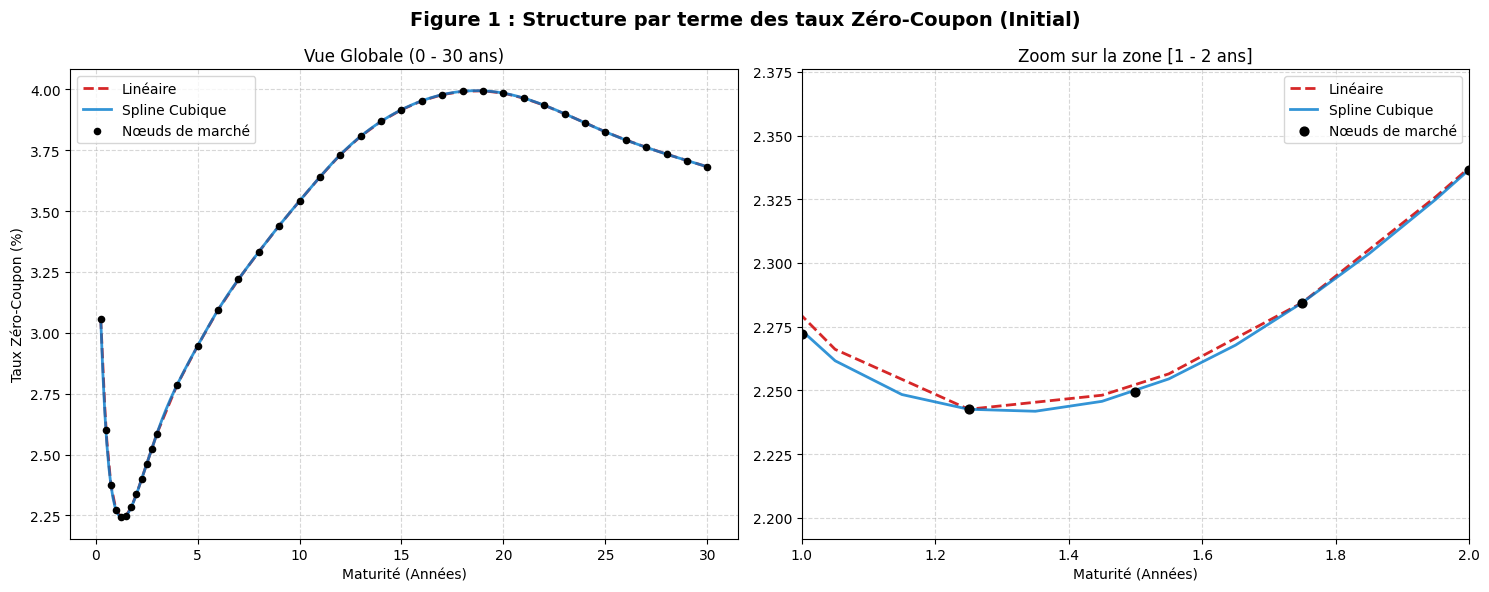

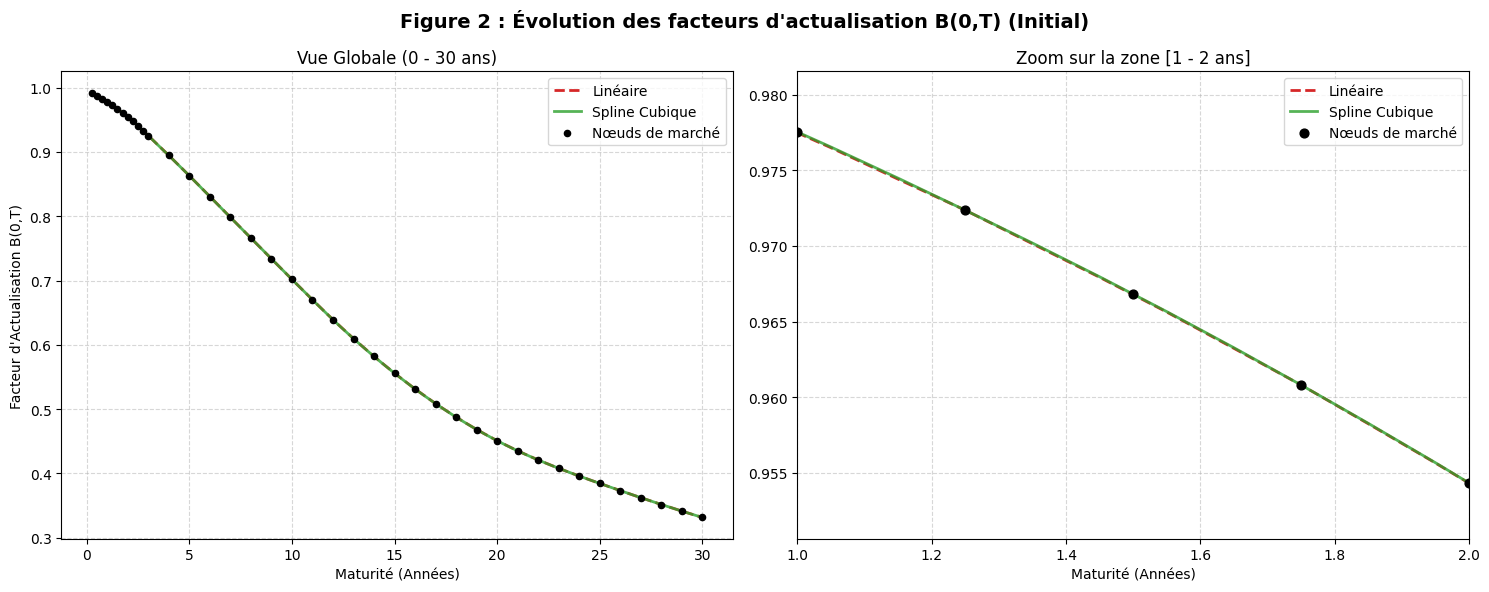

In [19]:
# On génère l'interpolation et on trace les figures pour la courbe de base
f_lin_init, f_spl_init, T_dense_init = interpolate_and_plot_zc(df_results_initial, plot_graphs=True, titre_suffixe="(Initial)")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# FONCTION : Calcul et tracé de la courbe Forward (Macro + Zoom)
# ==========================================
def calculate_and_plot_forward(f_lineaire, f_spline, T_market, delta=0.25, plot_graphs=True, titre_suffixe=""):
    """
    Calcule les taux forwards continus à partir des fonctions d'interpolation ZC.
    Génère la grille temporelle adaptée et trace un comparatif global + zoom.

    Paramètres :
    - f_lineaire, f_spline : Fonctions d'interpolation (issues de interpolate_and_plot_zc)
    - T_market : Tableau ou Serie des maturités du marché (pour connaître les bornes)
    - delta : Tenor du forward (ex: 0.25 pour 3 Mois, 0.5 pour 6 Mois)

    Retourne : Fwd_lineaire, Fwd_spline, T_fwd
    """

    # 1. Création de la grille d'évaluation SÉCURISÉE (pas = 0.1 an)
    T_fwd_max = T_market.max() - delta
    T_fwd = np.arange(T_market.min(), T_fwd_max, 0.1)
    T_fwd = np.append(T_fwd, T_fwd_max)

    # 2. Fonction interne de calcul vectorisé du Forward
    def eval_forward(T_array, func_interp, d):
        R_T = func_interp(T_array) / 100
        R_T_d = func_interp(T_array + d) / 100

        B_T = np.exp(-R_T * T_array)
        B_T_d = np.exp(-R_T_d * (T_array + d))

        return (1 / d) * ((B_T / B_T_d) - 1) * 100

    # 3. Évaluation des Forwards pour les deux méthodes
    Fwd_lineaire = eval_forward(T_fwd, f_lineaire, delta)
    Fwd_spline = eval_forward(T_fwd, f_spline, delta)

    # Paramètres de la fenêtre de zoom
    zoom_min = 9.0
    zoom_max = 14.0
    mask = (T_fwd >= zoom_min) & (T_fwd <= zoom_max)

    # 4. Tracé des graphiques
    if plot_graphs:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Couleurs demandées : Rouge (Linéaire) et Bleu (Spline)
        color_lin = '#d62728' # Rouge
        color_spl = '#007acc' # Bleu

        # --- Ax1 : Vue Globale ---
        ax1.plot(T_fwd, Fwd_lineaire, color=color_lin, linestyle='--', linewidth=2, label=f'Forward {int(delta*12)}M (Linéaire)')
        ax1.plot(T_fwd, Fwd_spline, color=color_spl, linestyle='-', linewidth=2, alpha=0.8, label=f'Forward {int(delta*12)}M (Spline Cubique)')

        ax1.set_title("Vue Globale (0 - 30 ans)", fontsize=12)
        ax1.set_xlabel('Maturité T (Années)', fontsize=11)
        ax1.set_ylabel(f'Taux Forward {int(delta*12)}M (%)', fontsize=11)
        ax1.grid(True, linestyle='--', alpha=0.5)
        ax1.legend()

        # --- Ax2 : Vue Zoomée [9 - 14 ans] ---
        ax2.plot(T_fwd, Fwd_lineaire, color=color_lin, linestyle='--', linewidth=2, label=f'Forward {int(delta*12)}M (Linéaire)')
        ax2.plot(T_fwd, Fwd_spline, color=color_spl, linestyle='-', linewidth=2, alpha=0.8, label=f'Forward {int(delta*12)}M (Spline Cubique)')

        ax2.set_xlim(zoom_min, zoom_max)

        # Ajustement dynamique de l'axe Y pour bien voir l'écart
        y_min_zoom = min(Fwd_lineaire[mask].min(), Fwd_spline[mask].min())
        y_max_zoom = max(Fwd_lineaire[mask].max(), Fwd_spline[mask].max())
        ax2.set_ylim(y_min_zoom - 0.1, y_max_zoom + 0.1) # Marge de 10 bps haut/bas

        ax2.set_title(f"Zoom sur la zone [{int(zoom_min)} - {int(zoom_max)} ans]", fontsize=12)
        ax2.set_xlabel('Maturité T (Années)', fontsize=11)
        ax2.grid(True, linestyle='--', alpha=0.5)
        ax2.legend()

        # Titre général
        titre = f"Figure 3 : Impact de l'interpolation sur les Taux Forward {int(delta*12)}M"
        if titre_suffixe:
            titre += f" {titre_suffixe}"

        plt.suptitle(titre, fontsize=14, fontweight='bold')
        plt.tight_layout()

        # Sauvegarde dynamique
        filename = f"Figure_3_Forwards_{int(delta*12)}M_Zoom_{titre_suffixe.replace(' ', '_')}.png" if titre_suffixe else f"Figure_3_Forwards_{int(delta*12)}M_Zoom.png"
        plt.savefig(filename, dpi=300)
        plt.show()

    return Fwd_lineaire, Fwd_spline, T_fwd

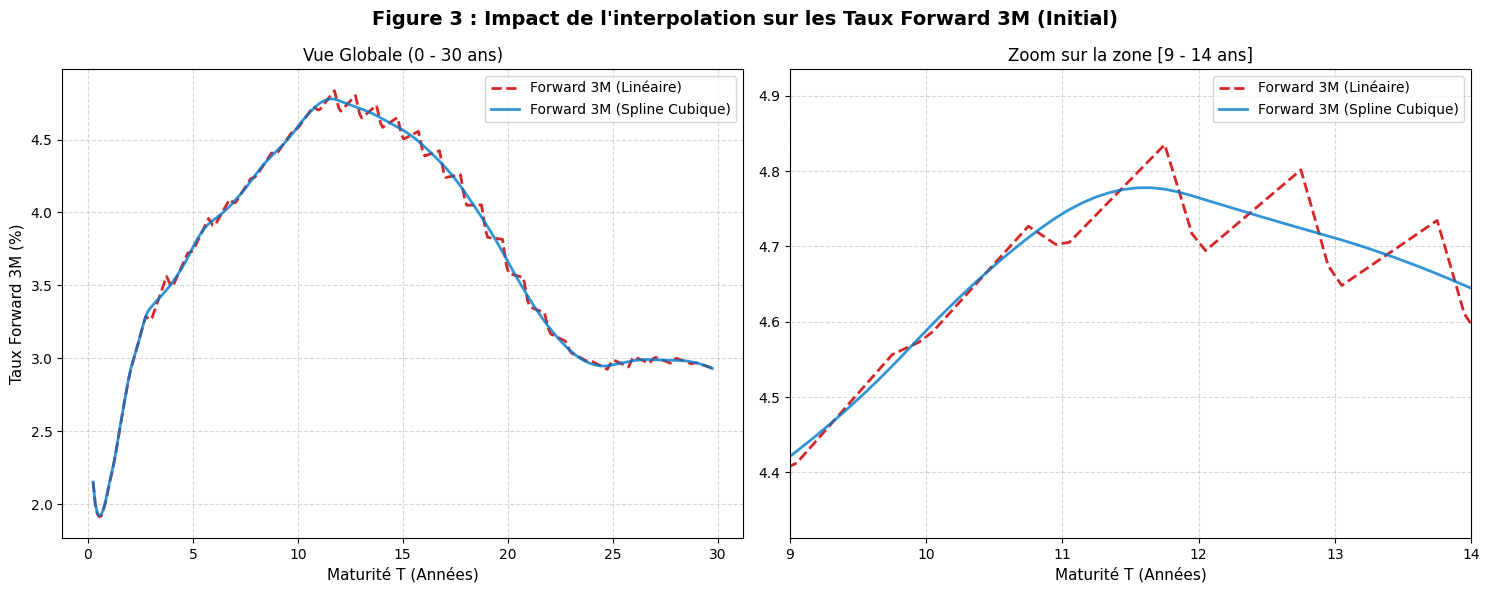

In [ ]:
# 3. On génère la courbe Forward 3M (Question 1.3)
# 1. On récupère les maturités de marché pour les bornes
T_market_init = df_results_initial['Maturity'].values

Fwd_lin_init, Fwd_spl_init, T_fwd_init = calculate_and_plot_forward(
    f_lin_init,
    f_spl_init,
    T_market_init,
    delta=0.25,
    plot_graphs=True,
    titre_suffixe="(Initial)"
)

NameError: name 'stop' is not defined

2. Shifter le taux de swap 5Y de 10 bps

Choc appliqué sur : SWAP 5.0Y
Taux initial : 0.0297% | Taux choqué : 0.0307%

--- Tableau Comparatif des Taux Zéro-Coupon ---


,Maturité (Ans),Taux ZC Initial (%),Taux ZC Choqué (%),Écart (bps)
0,0.250000,3.0581,3.0581,0.00
1,0.500000,2.6022,2.6022,0.00
2,0.750000,2.3745,2.3745,0.00
3,1.000000,2.2720,2.2720,0.00
4,1.250000,2.2426,2.2426,0.00
5,1.500000,2.2495,2.2495,0.00
6,1.750000,2.2844,2.2844,0.00
7,2.000000,2.3363,2.3363,0.00
8,2.250000,2.3980,2.3980,0.00
9,2.500000,2.4599,2.4599,0.00


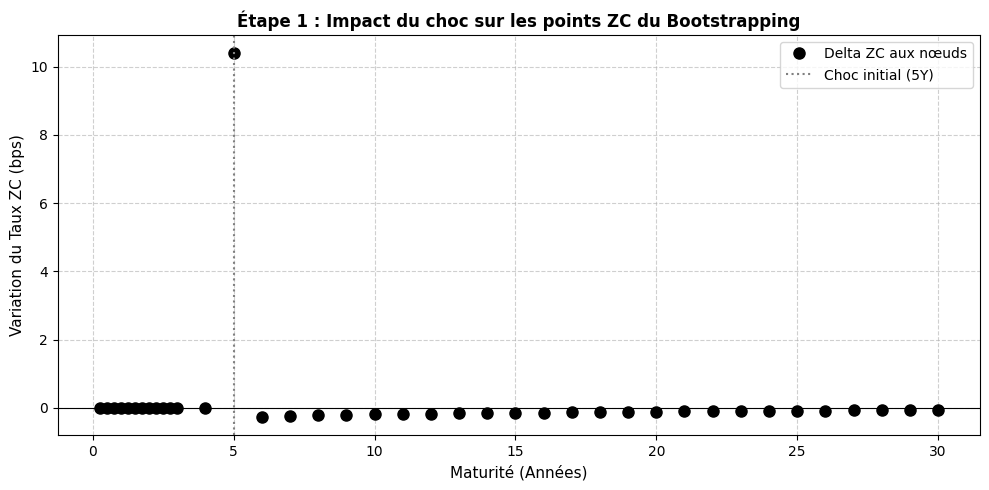

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ==========================================
# BLOC 1 : CHOC 5Y ET BOOTSTRAPPING BRUT
# ==========================================

# 1. Création du scénario choqué
df_shift_5Y = df_clean.copy()
index_5y = df_shift_5Y[df_shift_5Y['Maturity'] == 5.0].index[0]
# Attention : 10 bps = 0.10% = 0.0010 en décimal, selon comment tes taux sont formatés.
# Si tes taux sont en % dans la base (ex: 3.5), on ajoute 0.10.
df_shift_5Y.loc[index_5y, 'MarketRate'] += 0.10 *0.01

print(f"Choc appliqué sur : {df_clean.loc[index_5y, 'Instrument']} {df_clean.loc[index_5y, 'Maturity']}Y")
print(f"Taux initial : {df_clean.loc[index_5y, 'MarketRate']:.4f}% | Taux choqué : {df_shift_5Y.loc[index_5y, 'MarketRate']:.4f}%\n")

# 2. Bootstrapping des deux courbes
df_results_init = bootstrap_curve(df_clean)
df_results_shift = bootstrap_curve(df_shift_5Y)

# 3. Calcul du Delta ZC sur les nœuds EXACTS du marché
T_market = df_results_init['Maturity'].values
# On multiplie par 100 pour passer des % aux points de base (bps)
Delta_ZC_nodes = (df_results_shift['ZeroCouponRate'] - df_results_init['ZeroCouponRate']) * 100

# ==========================================
# NOUVEAU : CRÉATION ET AFFICHAGE DU DATAFRAME
# ==========================================
df_comparaison = pd.DataFrame({
    'Maturité (Ans)': T_market,
    'Taux ZC Initial (%)': df_results_init['ZeroCouponRate'],
    'Taux ZC Choqué (%)': df_results_shift['ZeroCouponRate'],
    'Écart (bps)': Delta_ZC_nodes
})

print("--- Tableau Comparatif des Taux Zéro-Coupon ---")
# On formate l'affichage pour que ce soit bien lisible (4 décimales pour les %, 2 pour les bps)
display(df_comparaison.style.format({
    'Taux ZC Initial (%)': '{:.4f}',
    'Taux ZC Choqué (%)': '{:.4f}',
    'Écart (bps)': '{:.2f}'
}))
print("\n")


# 4. Tracé des points discrets (Preuve qu'il n'y a RIEN avant 5 ans)
plt.figure(figsize=(10, 5))
plt.plot(T_market, Delta_ZC_nodes, marker='o', linestyle='None', color='black', markersize=8, label='Delta ZC aux nœuds')
plt.axvline(x=5.0, color='gray', linestyle=':', label='Choc initial (5Y)')
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Étape 1 : Impact du choc sur les points ZC du Bootstrapping', fontsize=12, fontweight='bold')
plt.xlabel('Maturité (Années)', fontsize=11)
plt.ylabel('Variation du Taux ZC (bps)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

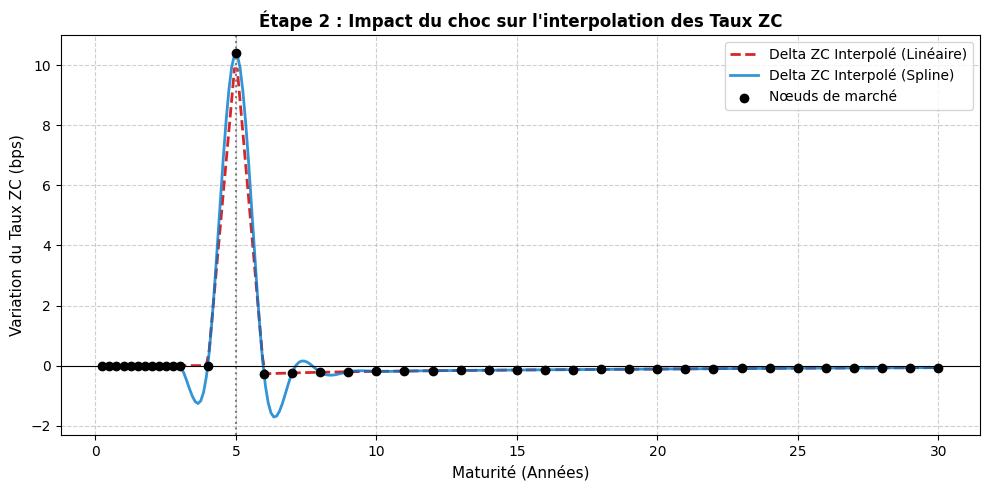

In [26]:
# ==========================================
# BLOC 2 : INTERPOLATION ET DELTAS DES COURBES ZC
# ==========================================
from scipy.interpolate import interp1d, CubicSpline

# 1. Création des fonctions d'interpolation pour les deux scénarios
R_init = df_results_init['ZeroCouponRate'].values
R_shift = df_results_shift['ZeroCouponRate'].values

f_lin_init = interp1d(T_market, R_init, kind='linear')
f_spl_init = CubicSpline(T_market, R_init)

f_lin_shift = interp1d(T_market, R_shift, kind='linear')
f_spl_shift = CubicSpline(T_market, R_shift)

# 2. Grille dense d'évaluation
T_dense = np.arange(T_market.min(), T_market.max(), 0.1)
T_dense = np.append(T_dense, T_market.max())

# 3. Calcul des Deltas interpolés (en bps)
Delta_ZC_lin = (f_lin_shift(T_dense) - f_lin_init(T_dense)) * 100
Delta_ZC_spl = (f_spl_shift(T_dense) - f_spl_init(T_dense)) * 100

# 4. Tracé
plt.figure(figsize=(10, 5))
plt.plot(T_dense, Delta_ZC_lin, color='#d62728', linestyle='--', linewidth=2, label='Delta ZC Interpolé (Linéaire)')
plt.plot(T_dense, Delta_ZC_spl, color='#007acc', linestyle='-', linewidth=2, alpha=0.8, label='Delta ZC Interpolé (Spline)')
plt.scatter(T_market, Delta_ZC_nodes, color='black', zorder=5, label='Nœuds de marché')

plt.axvline(x=5.0, color='gray', linestyle=':')
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title("Étape 2 : Impact du choc sur l'interpolation des Taux ZC", fontsize=12, fontweight='bold')
plt.xlabel('Maturité (Années)', fontsize=11)
plt.ylabel('Variation du Taux ZC (bps)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

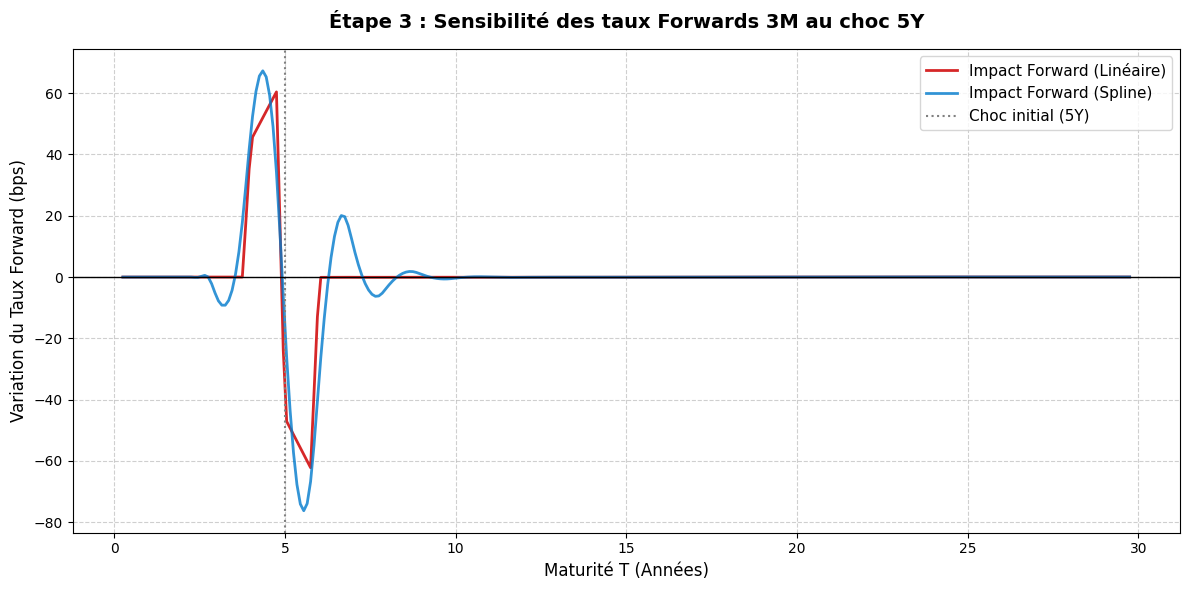

In [27]:
# ==========================================
# BLOC 3 : CALCUL DES FORWARDS ET DELTAS FORWARDS
# ==========================================

delta_tenor = 0.25 # Forward 3M

# 1. On utilise notre fonction robuste pour calculer les Forwards
Fwd_lin_init, Fwd_spl_init, T_fwd = calculate_and_plot_forward(
    f_lin_init, f_spl_init, T_market, delta=delta_tenor, plot_graphs=False
)

Fwd_lin_shift, Fwd_spl_shift, _ = calculate_and_plot_forward(
    f_lin_shift, f_spl_shift, T_market, delta=delta_tenor, plot_graphs=False
)

# 2. Calcul des Deltas Forwards (en bps)
Delta_Fwd_lin = (Fwd_lin_shift - Fwd_lin_init) * 100
Delta_Fwd_spl = (Fwd_spl_shift - Fwd_spl_init) * 100

# 3. Tracé final
plt.figure(figsize=(12, 6))

plt.plot(T_fwd, Delta_Fwd_lin, color='#d62728', linestyle='-', linewidth=2, label='Impact Forward (Linéaire)')
plt.plot(T_fwd, Delta_Fwd_spl, color='#007acc', linestyle='-', linewidth=2, alpha=0.8, label='Impact Forward (Spline)')

plt.axvline(x=5.0, color='gray', linestyle=':', label='Choc initial (5Y)')
plt.axhline(y=0, color='black', linewidth=1)

plt.title('Étape 3 : Sensibilité des taux Forwards 3M au choc 5Y', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Maturité T (Années)', fontsize=12)
plt.ylabel('Variation du Taux Forward (bps)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

les vaguelettes proviennent de l'interpolation polynomial.
L'interpolation linéaire localise parfaitement le risque (idéal pour la couverture/hedging) mais produit des taux forwards discontinus (inutilisables pour le pricing). L'interpolation par Spline produit des courbes lisses et réalistes (idéal pour le pricing) mais diffuse le risque sur toute la courbe (effet de pollution globale), rendant la lecture des sensibilités plus complexe.

# Partie 2 

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from IPython.display import display

# ==========================================
# 1. DONNÉES DU TABLEAU 1 (Moneyness / Strikes relatifs)
# ==========================================
donnees_tableau_1 = {
    'Relative_Strike_bps': [-100, -50, -25, 0, 25, 50, 100],
    'Volatilite_Caplets_pct': [31.2, 28.4, 26.6, 25.0, 24.4, 25.0, 27.2]
}
df_table1 = pd.DataFrame(donnees_tableau_1)

# ==========================================
# 2. PARAMÈTRES DU MARCHÉ (RAPPEL)
# ==========================================
delta = 1.0
T_fixing = 5.0
T_paiement = 6.0
Nominal = 10000

# On suppose que B_4 et B_5 ont été extraits de df_results_init
B_5 = df_results_init.loc[df_results_init['Maturity'] == T_fixing, 'DiscountFactor'].values[0]
B_6 = df_results_init.loc[df_results_init['Maturity'] == T_paiement, 'DiscountFactor'].values[0]
# B_6 = df_results_init.loc[df_results_init['Maturity'] == 6, 'DiscountFactor'].values[0]

# Calcul du Taux Forward L_i(0)
L_forward = (1 / delta) * ((B_5 / B_6) - 1)

print("--- PARAMÈTRES DE BASE ---")
print(f"Taux Forward L_i(0)       : {L_forward*100:.4f} %")
print(f"Discount Factor B(0, 5)   : {B_5:.6f}")
print(f"Discount Factor B(0, 6)   : {B_6:.6f}\n")

# ==========================================
# 3. FONCTION DE PRICING BLACK
# ==========================================
def price_caplet_black(F, K, sigma, T_fixing, B_paiement, delta, N=10000):
    """
    Calcule le prix d'un caplet selon la formule de Black (1976).
    """
    if K <= 0 or F <= 0:
        return np.nan

    d1 = (np.log(F / K) + 0.5 * (sigma**2) * T_fixing) / (sigma * np.sqrt(T_fixing))
    d2 = d1 - sigma * np.sqrt(T_fixing)

    Nd1 = norm.cdf(d1)
    Nd2 = norm.cdf(d2)

    return N * delta * B_paiement * (F * Nd1 - K * Nd2)

# ==========================================
# 4. CALCUL DES PRIX DE MARCHÉ
# ==========================================
resultats_caplets = []

for index, row in df_table1.iterrows():
    # 1. Spread en décimales
    spread_decimal = row['Relative_Strike_bps'] / 10000

    # 2. Strike Absolu (K = F + spread)
    K_absolu = L_forward + spread_decimal

    # 3. Volatilité en décimales
    sigma_decimal = row['Volatilite_Caplets_pct'] / 100

    # 4. Pricing en Euros
    prix_euros = price_caplet_black(
        F = L_forward,
        K = K_absolu,
        sigma = sigma_decimal,
        T_fixing = T_fixing,
        B_paiement = B_6,
        delta = delta,
        N = Nominal
    )

    # 5. Pricing en Pourcentage du Nominal
    prix_pct = (prix_euros / Nominal) * 100

    resultats_caplets.append({
        'Rel. Strike (bps)': row['Relative_Strike_bps'],
        'Strike Absolu K (%)': K_absolu * 100,
        'Volatilité (%)': row['Volatilite_Caplets_pct'],
        'Prix Caplet (€)': prix_euros,
        'Prix Caplet (%)': prix_pct  # <-- La nouvelle colonne !
    })

df_prix_caplets = pd.DataFrame(resultats_caplets)

print("--- RÉSULTATS DE LA VALORISATION : SOURIRE DE VOLATILITÉ ---")
display(df_prix_caplets.style.format({
    'Rel. Strike (bps)': '{:+.0f}',
    'Strike Absolu K (%)': '{:.4f}%',
    'Volatilité (%)': '{:.1f}%',
    'Prix Caplet (€)': '{:.2f} €',
    'Prix Caplet (%)': '{:.4f} %'  # Formatage à 4 décimales
}))

--- PARAMÈTRES DE BASE ---
Taux Forward L_i(0)       : 3.9030 %
Discount Factor B(0, 5)   : 0.863028
Discount Factor B(0, 6)   : 0.830609

--- RÉSULTATS DE LA VALORISATION : SOURIRE DE VOLATILITÉ ---


,Rel. Strike (bps),Strike Absolu K (%),Volatilité (%),Prix Caplet (€),Prix Caplet (%)
0,-100,2.9030%,31.2%,125.14 €,1.2514 %
1,-50,3.4030%,28.4%,98.06 €,0.9806 %
2,-25,3.6530%,26.6%,84.20 €,0.8420 %
3,+0,3.9030%,25.0%,71.37 €,0.7137 %
4,+25,4.1530%,24.4%,62.00 €,0.6200 %
5,+50,4.4030%,25.0%,56.88 €,0.5688 %
6,+100,4.9030%,27.2%,51.72 €,0.5172 %


### Q1 
Le modèle standard de marché est le Modèle de Black (aussi appelé Black-76).Les caplets et floorlets ne sont pas cotés en prix, mais en volatilité implicite (la volatilité $\sigma$ qu'il faut injecter dans la formule de Black).Référence Cours :
* Slide 194 : "Le modèle de Black : la référence du marché. Les produits dérivés standards (caps, floors...) sont des options européennes dont les prix sont obtenus dans le modèle de Black." * Slide 197 : "Les caplets et floorlets sont cotés en volatilité, la volatilité implicite de la formule de Black." 

### Question 2 : EDS des taux Libor forwards et Probabilité associée

**1. La Probabilité Associée**
Pour valoriser un Caplet payant à la date $T_i$, on se place sous la **Probabilité Forward Neutre**, notée $\mathbb{Q}^{T_i}$.
* **Numéraire associé :** Le Zéro-Coupon de maturité $T_i$, noté $P(t, T_i)$ ou $B(t, T_i)$.
* **Propriété fondamentale :** Sous cette mesure de probabilité, le taux Forward $L_i(t)$ est une **martingale** (il n'a pas de tendance, son espérance mathématique correspond à sa valeur actuelle).
* *(Référence cours : Slide 192)*

**2. L'Équation Différentielle Stochastique (EDS)**
Dans le modèle de marché (Modèle de Black), le taux Forward suit un **Mouvement Brownien Géométrique** (Lognormal) sous la probabilité Forward Neutre. L'équation de diffusion est :

$$\frac{dL_i(t)}{L_i(t)} = \sigma_i dW_t^{\mathbb{Q}^{T_i}}$$

Soit :
$$dL_i(t) = \sigma_i L_i(t) dW_t^{\mathbb{Q}^{T_i}}$$

Où :
* $L_i(t)$ est le taux Forward Libor/Euribor observé en $t$.
* $\sigma_i$ est la volatilité implicite du taux (Black volatility).
* $dW_t^{\mathbb{Q}^{T_i}}$ est un Mouvement Brownien standard sous la mesure $\mathbb{Q}^{T_i}$.

*(Référence cours : Slide 200)*

### Question 3 : Formules de valorisation des Caplets et Floorlets

Dans le cadre du modèle de marché (Modèle de Black), les Caplets et Floorlets sont valorisés comme des options européennes sur le taux Forward.

**1. Formule du Caplet (Call sur taux)**
Un Caplet de strike $K$, portant sur la période $[T_{i-1}, T_i]$ et payé en $T_i$, est valorisé ainsi :

$$\text{Caplet}(t) = N \cdot \delta_i \cdot B(t, T_i) \cdot \left[ L_i(t) \Phi(d_1) - K \Phi(d_2) \right]$$

*(Référence cours : **Slide 201**)*

**2. Formule du Floorlet (Put sur taux)**
Un Floorlet de strike $K$ est valorisé ainsi :

$$\text{Floorlet}(t) = N \cdot \delta_i \cdot B(t, T_i) \cdot \left[ -L_i(t) \Phi(-d_1) + K \Phi(-d_2) \right]$$

*(Référence cours : **Slide 202**)*

**3. Définition des paramètres**

Les termes $d_1$ et $d_2$ sont définis par :

$$d_1 = \frac{\ln\left(\frac{L_i(t)}{K}\right) + \frac{1}{2}\sigma_i^2 (T_{i-1}-t)}{\sigma_i \sqrt{T_{i-1}-t}}$$

$$d_2 = d_1 - \sigma_i \sqrt{T_{i-1}-t}$$

Où :
* **$N$** : Le montant notionnel (Nominal).
* **$\delta_i$** : La fraction d'année (Year fraction) correspondant à la période $[T_{i-1}, T_i]$.
* **$B(t, T_i)$** : Le facteur d'actualisation (Zero-Coupon) à la date de paiement.
* **$L_i(t)$** : Le taux Forward actuel pour la période concernée.
* **$\sigma_i$** : La volatilité implicite (Black volatility) du Caplet.
* **$\Phi$** : La fonction de répartition de la loi Normale centrée réduite $\mathcal{N}(0,1)$.

### Question 4

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

# ==============================================================================
# 1. RÉCUPÉRATION DES DONNÉES DU TABLEAU 1 (Stock / Vol)
# ==============================================================================
# On lit la plage I3:P5.
# Astuce : On charge la feuille et on cible les lignes/colonnes spécifiques
# I est la 9ème colonne (index 8), P est la 16ème (index 15)
df_raw = pd.read_excel('Data.xlsm', sheet_name='Interpo', header=None)

# Ligne 1 du tableau (Row 2 du fichier) : Les Strikes Relatifs en bps
rel_strikes_bps = df_raw.iloc[2, 9:16].values.astype(float) # Valeurs: -100, -50, ...

# Ligne 2 du tableau (Row 3 du fichier) : Les Volatilités Caplets
vols_caplets = df_raw.iloc[3, 9:16].values.astype(float)    # Valeurs: ~31%, 28%...

print("Données récupérées du Tableau 1 :")
print(f"Strikes (bps): {rel_strikes_bps}")
print(f"Volatilités  : {vols_caplets}")

import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.interpolate import interp1d

# ==============================================================================
# 1. PARAMÈTRES DE MARCHÉ CORRIGÉS (Option Expiry = 5Y)
# ==============================================================================
# Caplet "Maturité 5Y" au sens Option = Fixing dans 5 ans
T_fix = 5.0
T_pay = 6.0
delta = 1.0

# Interpolation de la courbe existante (df_results)
f_interp = interp1d(df_results['Maturity'], df_results['ZeroCouponRate'],
                    kind='linear', fill_value='extrapolate')
def get_df(t):
    return np.exp(-f_interp(t) * t)

B_pay = get_df(T_pay) # B(0, 6)
B_fix = get_df(T_fix) # B(0, 5)
L_fwd = (B_fix / B_pay - 1) / delta

print(f"--- Paramètres Corrigés (Alignement Prof) ---")
print(f"Période          : {T_fix} ans à {T_pay} ans")
print(f"Forward L({int(T_fix)}, {int(T_pay)})   : {L_fwd:.4%}") # Doit être ~3.9030%
print(f"Discount B(0, {int(T_pay)}) : {B_pay:.4f}")

# ==============================================================================
# 2. DONNÉES TABLEAU 1 (Récupérées précédemment)
# ==============================================================================
# J'utilise les données que nous avions extraites (I3:P5)
# Attention : Assurons-nous que ce sont bien les vols pour l'échéance 5Y
data_market = [
    (-100, 0.3119),
    (-50,  0.2829),
    (-25,  0.2662),
    (0,    0.2497), # ATM
    (25,   0.2432),
    (50,   0.2493),
    (100,  0.2718)
]

# ==============================================================================
# 3. CALCUL DES PRIX
# ==============================================================================
results = []
for rel_k, sigma in data_market:
    # Strike Absolu = Forward (3.90%) + Spread
    K = L_fwd + rel_k / 10000.0

    # Formule de Black (T_fix = 5.0)
    d1 = (np.log(L_fwd / K) + 0.5 * sigma**2 * T_fix) / (sigma * np.sqrt(T_fix))
    d2 = d1 - sigma * np.sqrt(T_fix)

    price = delta * B_pay * (L_fwd * norm.cdf(d1) - K * norm.cdf(d2))

    results.append({
        'Strike Relatif (bps)': int(rel_k),
        'Strike Absolu': f"{K:.4%}",
        'Volatilité': f"{sigma:.2%}",
        'Prix Caplet': round(price *100, 6)
    })

df_prices_prof = pd.DataFrame(results)
display(df_prices_prof)

Données récupérées du Tableau 1 :
Strikes (bps): [-100.  -50.  -25.    0.   25.   50.  100.]
Volatilités  : [0.31185914 0.28327436 0.26592149 0.25       0.24345088 0.24901901
 0.27182778]
--- Paramètres Corrigés (Alignement Prof) ---
Période          : 5.0 ans à 6.0 ans
Forward L(5, 6)   : 3.9030%
Discount B(0, 6) : 0.8306


,Strike Relatif (bps),Strike Absolu,Volatilité,Prix Caplet
0,-100,2.9030%,31.19%,1.251171
1,-50,3.4030%,28.29%,0.977801
2,-25,3.6530%,26.62%,0.842548
3,0,3.9030%,24.97%,0.712844
4,25,4.1530%,24.32%,0.617723
5,50,4.4030%,24.93%,0.566826
6,100,4.9030%,27.18%,0.516584


On peut aller jusuq'à la partie 3.7 avec l'avancement actuel du cours. 

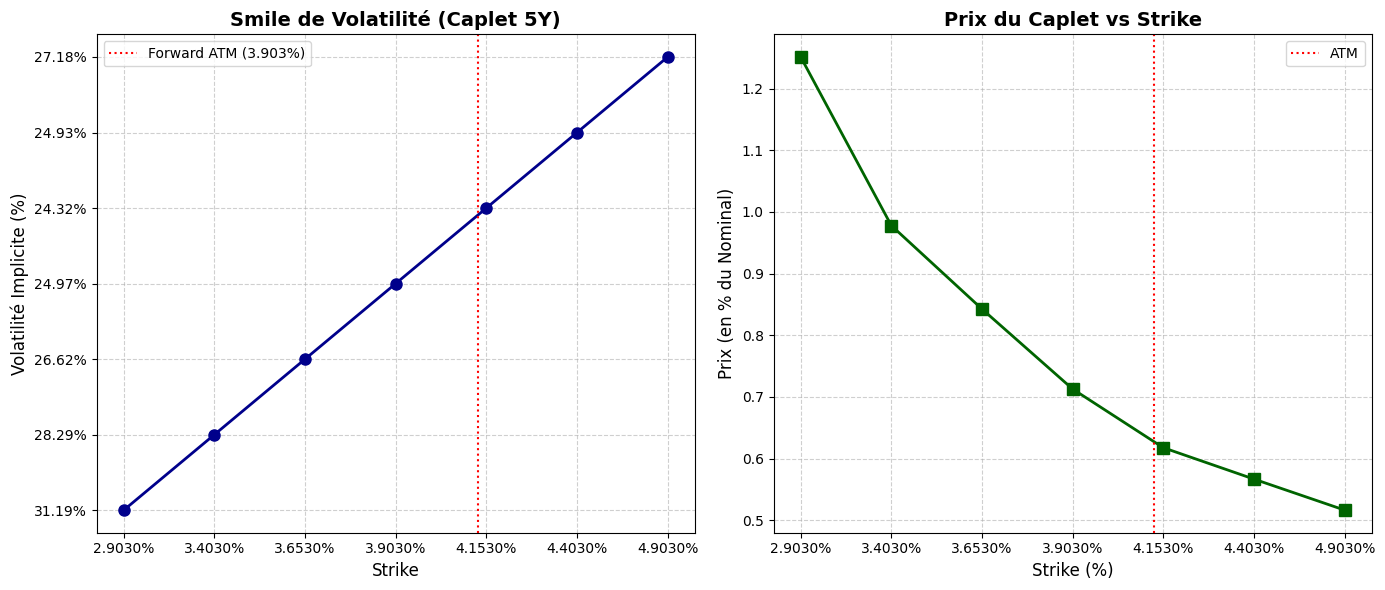

In [ ]:
df_plot = df_prices_prof.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Graphique 1 : Le Smile de Volatilité ---
# On trace la Volatilité en fonction du Strike Absolu
ax1.plot(df_plot['Strike Absolu'], df_plot['Volatilité'],
         marker='o', linestyle='-', color='darkblue', linewidth=2, markersize=8)

# Mise en forme
ax1.set_title('Smile de Volatilité (Caplet 5Y)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Strike', fontsize=12)
ax1.set_ylabel('Volatilité Implicite (%)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Ajout d'une ligne verticale pour le Forward (ATM)
atm_strike = 3.9030 # Le strike à 0 bps
ax1.axvline(x=atm_strike, color='red', linestyle=':', label=f'Forward ATM ({atm_strike}%)')
ax1.legend()

# --- Graphique 2 : Le Prix du Caplet ---
# On trace le Prix en fonction du Strike
ax2.plot(df_plot['Strike Absolu'], df_plot['Prix Caplet'],
         marker='s', linestyle='-', color='darkgreen', linewidth=2, markersize=8)

# Mise en forme
ax2.set_title('Prix du Caplet vs Strike', fontsize=14, fontweight='bold')
ax2.set_xlabel('Strike (%)', fontsize=12)
ax2.set_ylabel('Prix (en % du Nominal)', fontsize=12) # Supposé en % vu les valeurs > 1
ax2.grid(True, linestyle='--', alpha=0.6)

# Ajout d'une ligne verticale pour le Forward (ATM)
ax2.axvline(x=atm_strike, color='red', linestyle=':', label='ATM')
ax2.legend()

plt.tight_layout()
plt.show()

Dans 3.4, utiliser vriant lemme d'ito appliqué au processus Zt.  on va montrer que la dynamique du processus lit est log normale shiftée . ça génère du scew. c'est une des limitation du model uell white. Capature mal le scew, smile de volatilité.

